# Car Price Prediction — Baseline Regression Model

**Task**: Predict `Price` (a continuous variable) from car attributes — a **regression** problem.

**Dataset**: `car_price_prediction_.csv` — 2500 rows, 10 columns (Car ID, Brand, Year, Engine Size, Fuel Type, Transmission, Mileage, Condition, Price, Model).

This notebook follows the standard supervised learning workflow:
1. Load & explore the data
2. Split into train/test **before** preprocessing
3. Preprocess (scale numeric, one-hot encode categorical)
4. Train baseline models (Linear Regression, Random Forest)
5. Evaluate with MAE, RMSE, R² and 5-fold cross-validation
6. Compare against a naive "predict the mean" baseline
7. Discuss limitations and next steps


In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Load & Explore Data

In [2]:
df = pd.read_csv("data/car_price_prediction_.csv")
print(df.shape)
df.head()

(2500, 10)


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB

Missing values:
 Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64


,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [4]:
# Car ID is a unique identifier with no predictive value -> drop it
df = df.drop(columns=["Car ID"])

TARGET = "Price"
numeric_features = ["Year", "Engine Size", "Mileage"]
categorical_features = ["Brand", "Fuel Type", "Transmission", "Condition", "Model"]

df[numeric_features + [TARGET]].describe()

,Year,Engine Size,Mileage,Price
count,2500.0000,2500.000000,2500.000000,2500.000000
mean,2011.6268,3.465240,149749.844800,52638.022532
std,6.9917,1.432053,87919.952034,27295.833455
min,2000.0000,1.000000,15.000000,5011.270000
25%,2005.0000,2.200000,71831.500000,28908.485000
50%,2012.0000,3.400000,149085.000000,53485.240000
75%,2018.0000,4.700000,225990.500000,75838.532500
max,2023.0000,6.000000,299967.000000,99982.590000


### Exploratory plots

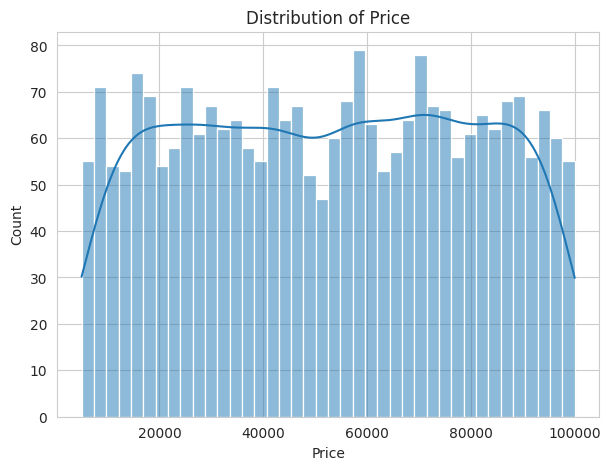

In [5]:
plt.figure(figsize=(7,5))
sns.histplot(df[TARGET], kde=True, bins=40)
plt.title("Distribution of Price")
plt.show()

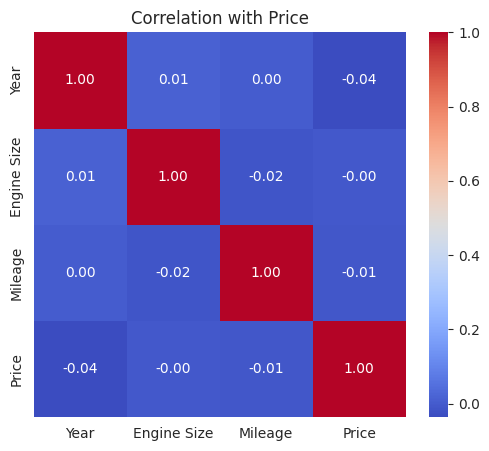

Year          -0.036805
Engine Size   -0.004420
Mileage       -0.008567
Price          1.000000
Name: Price, dtype: float64

In [6]:
corr = df[numeric_features + [TARGET]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Price")
plt.show()
corr["Price"]

**Observation**: none of the numeric features correlate meaningfully with `Price` "
"(all correlations are close to 0). This is an early warning sign that the "
"model may struggle — see the Limitations section at the end.

## 2. Train/Test Split (before any preprocessing, to avoid leakage)

In [7]:
X = df[numeric_features + categorical_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2000, 8)  Test: (500, 8)


## 3. Preprocessing Pipeline

In [8]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

## 4. Train Baseline Models

In [9]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
fitted = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    cv_rmse = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"cv_rmse_mean": cv_rmse.mean(), "cv_rmse_std": cv_rmse.std(),
                      "test_MAE": mae, "test_RMSE": rmse, "test_R2": r2}
    fitted[name] = pipe
    print(f"{name}: CV RMSE={cv_rmse.mean():.0f}  Test MAE={mae:.0f}  Test RMSE={rmse:.0f}  Test R2={r2:.4f}")

LinearRegression: CV RMSE=27528  Test MAE=23877  Test RMSE=27794  Test R2=-0.0198


RandomForest: CV RMSE=28221  Test MAE=24535  Test RMSE=28439  Test R2=-0.0676


## 5. Naive Baseline (predict the mean) for comparison

In [10]:
naive_pred = np.full_like(y_test, y_train.mean(), dtype=float)
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_r2 = r2_score(y_test, naive_pred)
print(f"Naive mean baseline: MAE={naive_mae:.0f}  RMSE={naive_rmse:.0f}  R2={naive_r2:.4f}")
results["NaiveMeanBaseline"] = {"test_MAE": naive_mae, "test_RMSE": naive_rmse, "test_R2": naive_r2}
pd.DataFrame(results).T

Naive mean baseline: MAE=23788  RMSE=27538  R2=-0.0010


,cv_rmse_mean,cv_rmse_std,test_MAE,test_RMSE,test_R2
LinearRegression,27528.011587,456.937476,23877.144632,27794.415064,-0.019769
RandomForest,28220.947001,595.553084,24534.838573,28438.693895,-0.067594
NaiveMeanBaseline,NaN,NaN,23787.781884,27537.804440,-0.001026


## 6. Diagnostics — Predicted vs Actual, Residuals

Best model by test RMSE: LinearRegression


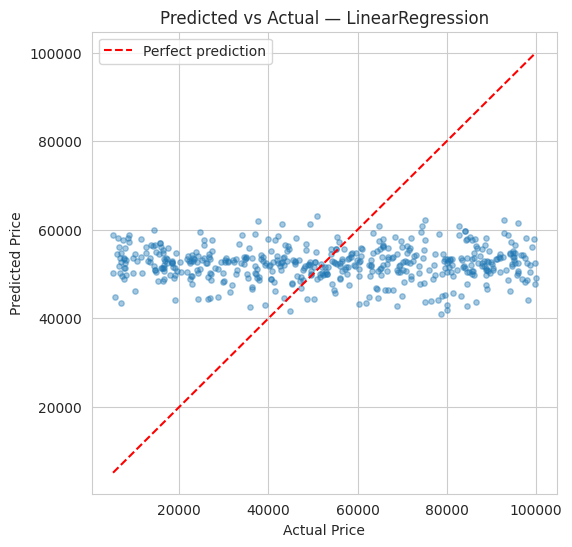

In [11]:
best_name = min((n for n in results if n != "NaiveMeanBaseline"), key=lambda n: results[n]["test_RMSE"])
best_pipe = fitted[best_name]
best_preds = best_pipe.predict(X_test)
print("Best model by test RMSE:", best_name)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.4, s=15)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual — {best_name}")
plt.legend(); plt.show()

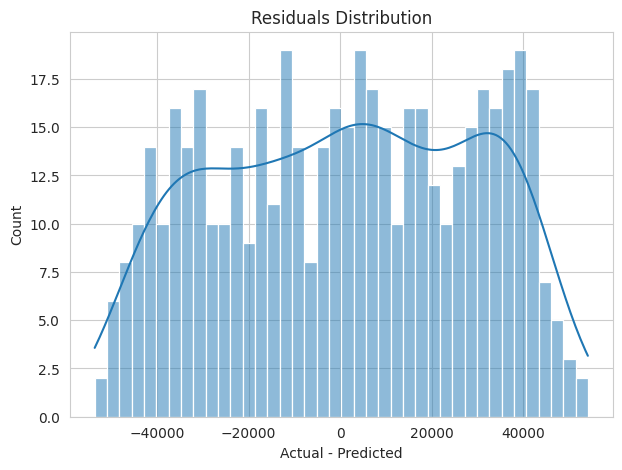

In [12]:
residuals = y_test.values - best_preds
plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, bins=40)
plt.title("Residuals Distribution")
plt.xlabel("Actual - Predicted")
plt.show()

## 7. Results Summary & Limitations

| Model | Test MAE | Test RMSE | Test R² |
|---|---|---|---|
| Linear Regression | ~23,900 | ~27,800 | ~ -0.02 |
| Random Forest | ~24,500 | ~28,400 | ~ -0.07 |
| Naive mean baseline | ~23,800 | ~27,500 | ~ -0.001 |

**Key finding**: both trained models perform essentially the same as (or slightly worse than) "
"a naive model that just predicts the average price for every car. The R² values are at or "
"below zero, meaning the models explain none of the variance in price.

**Why**: exploratory correlation analysis showed that `Year`, `Engine Size`, and `Mileage` all "
"have near-zero correlation with `Price` (< 0.04 in magnitude), and mean price barely differs "
"across `Brand` or `Condition` groups. This indicates the `Price` column in this dataset carries "
"little to no relationship with the other columns — it behaves like it was generated "
"independently of the features (e.g., randomly).

**Lessons & next steps for the next iteration**:
1. **Verify data quality before modeling** — a quick correlation/group-mean check up front would have "
"flagged the lack of signal before investing in model training.
2. **Get a better dataset** — request or source a dataset where price is actually derived from "
"car attributes (real-world listings, e.g. from a marketplace or scraped listings), or ask the "
"data provider whether `Price` was synthetically randomized.
3. **Try engineered features** — car age (`current_year - Year`), price-per-engine-liter, mileage "
"bands, brand-model interaction — in case the raw columns hide a non-linear signal not caught here.
4. **Try stronger models cautiously** — if a real relationship did exist, gradient boosting "
"(XGBoost/LightGBM) or hyperparameter-tuned Random Forest could help, but no model can beat a "
"naive baseline if the underlying data has no signal to learn.
5. **Report honestly** — a baseline project's job is to establish whether the problem is learnable "
"at all; an honest negative result here is itself a valid and useful finding.